<a href="https://colab.research.google.com/github/sahilchettri-data/esg_risk_analysis/blob/main/S%26P500ESGRiskAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S&P 500 ESG Risk Analysis

## Overview
This project analyzes ESG (Environmental, Social, and Governance) risk ratings for S&P 500 companies.
The dataset contains 503 companies across 11 sectors with individual E, S, and G risk scores sourced from Yahoo Finance via Kaggle.

## Objectives
- Identify which sectors carry the highest and lowest ESG risk
- Break down risk by Environmental, Social, and Governance dimensions
- Visualize patterns across sectors for sustainability-focused investment insight

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pritish509/s-and-p-500-esg-risk-ratings")

print("Path to dataset files:", path)

In [ ]:
import pandas as pd
import os

files = os.listdir(path)
print(files)

## 1. Data Loading & Cleaning
The dataset was sourced from Kaggle (S&P 500 ESG Risk Ratings).
After loading, 73 rows with missing ESG scores were dropped, leaving 430 companies for analysis.

In [ ]:
df = pd.read_csv(path + '/SP 500 ESG Risk Ratings.csv')

print(df.head())
print(df.columns)
df = df.dropna(subset=['Total ESG Risk score'])
print(df.shape)
print(df.isnull().sum())



## 2. Sector-Level Analysis
Grouping companies by sector to identify average ESG risk scores across Environmental, Social, and Governance dimensions.

In [ ]:
avgsecesg=df.groupby('Sector')['Total ESG Risk score'].mean()
highsec=avgsecesg.idxmax()
lowsec=avgsecesg.idxmin()
print(avgsecesg.sort_values())
print(f"Sector with the Lowest Total ESG Risk Score is {lowsec} sector while sector with the Highest Total ESG Risk Score is {highsec} sector.")

## 3. Visualizations

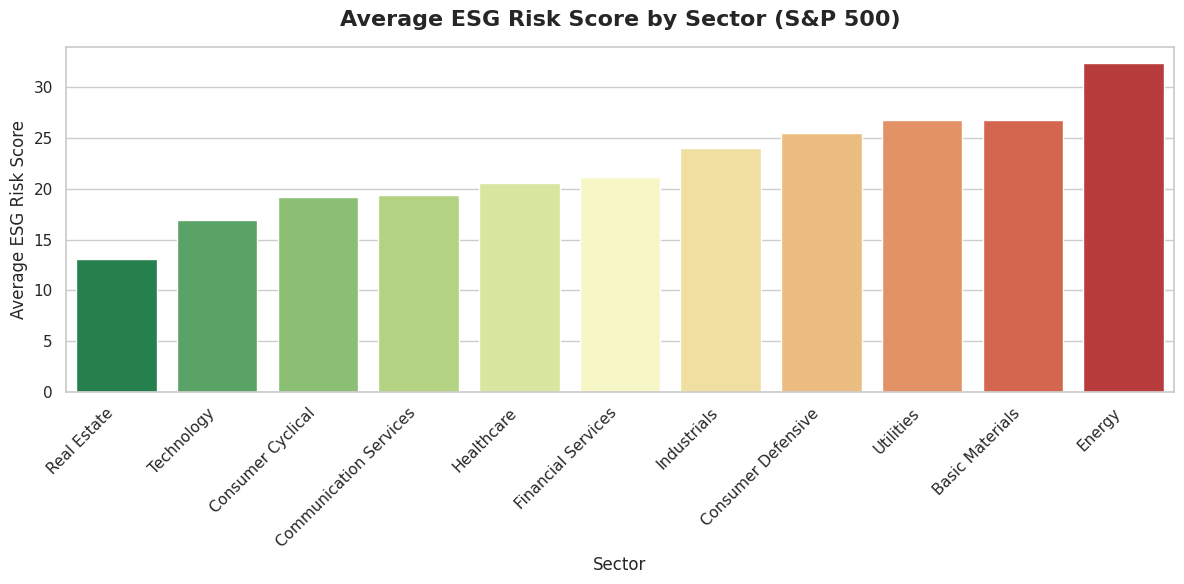

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

avgsecesg_df = avgsecesg.reset_index().sort_values('Total ESG Risk score')

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

bars = sns.barplot(data=avgsecesg_df, x='Sector', y='Total ESG Risk score',
                   palette='RdYlGn_r', hue='Sector', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Average ESG Risk Score by Sector (S&P 500)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Average ESG Risk Score', fontsize=12)
plt.tight_layout()
plt.show()


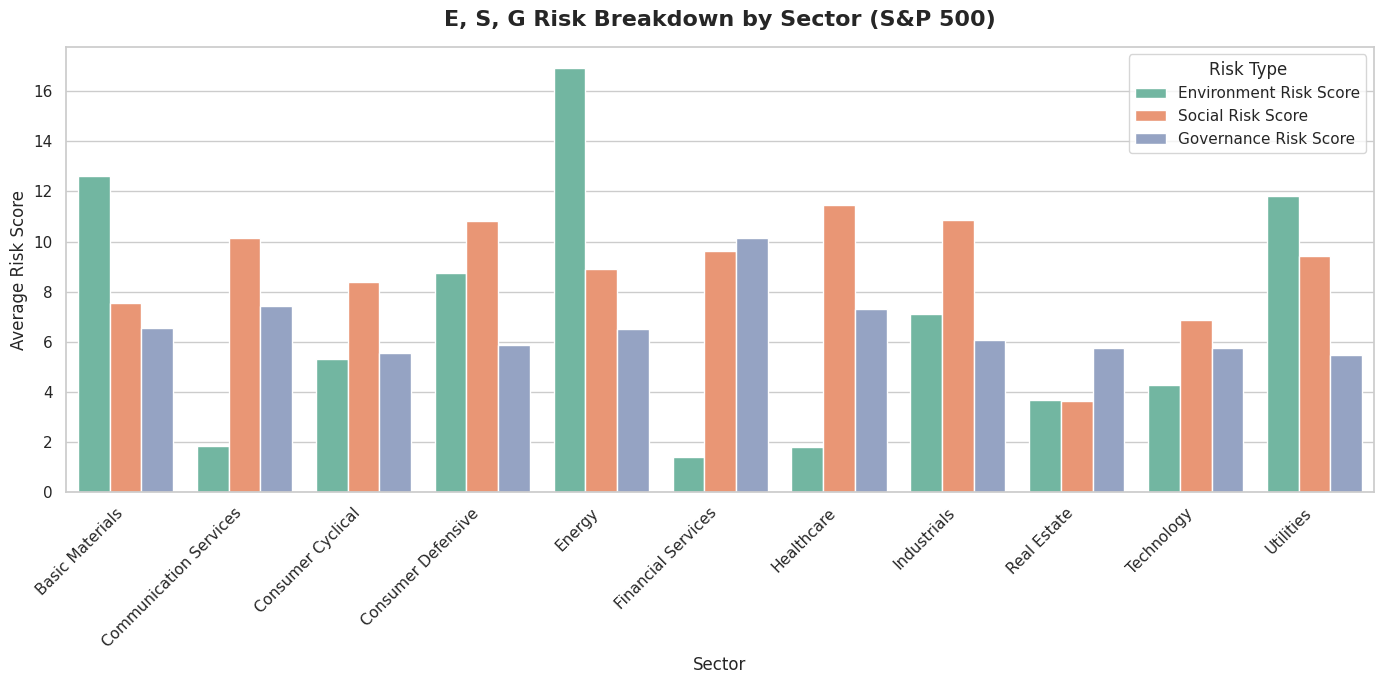

In [35]:
avg_scores = df.groupby('Sector')[['Total ESG Risk score', 'Environment Risk Score', 'Social Risk Score', 'Governance Risk Score']].mean().reset_index()
# print(avg_scores)

melted = avg_scores.melt(id_vars='Sector',
                          value_vars=['Environment Risk Score', 'Social Risk Score', 'Governance Risk Score'],
                          var_name='Risk Type',
                          value_name='Score')
plt.figure(figsize=(14, 7))
sns.barplot(data=melted, x='Sector', y='Score', hue='Risk Type', palette='Set2')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('E, S, G Risk Breakdown by Sector (S&P 500)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Average Risk Score', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Key Insights

- **Energy** sector carries the highest overall ESG risk, driven primarily by Environmental risk scores
- **Real Estate** sector has the lowest overall ESG risk
- **Healthcare** has the highest Social risk score, reflecting labor practices and patient rights concerns
- **Financial Services** has the highest Governance risk, consistent with regulatory and oversight challenges in the industry

*Analysis conducted using Python (Pandas, Seaborn, Matplotlib) on S&P 500 ESG Risk Ratings data.*